# 1. Introduction
This project aims to predict the hourly origin-destination ridership of KTM Komuter stations using machine learning techniques. Accurate ridership prediction helps in optimizing train schedules, resource allocation, and overall commuter experience.

# 2. Problem Statement
Public transportation services face challenges in matching capacity with demand. Overcrowding during peak hours and underutilization during off-peak hours lead to inefficiencies. This project solves this by treating ridership prediction as a Regression Problem, utilizing temporal and holiday features to forecast passenger volume.

# 3. Dataset Description
We use historical hourly ridership data across all KTM Komuter stations. The dataset includes temporal patterns and origin-destination matrices.

## Loading Dataset



In this section, we import all the necessary libraries for our machine learning project.


>These include `pandas` and `numpy` for
**data manipulation**, `matplotlib`, `seaborn`, and `plotly` for **data visualization**, and `holidays` for **handling holiday-related features**.

>We also import fucntions from `scikit-learn` for preprocessing, model training, evaluation, and hyperparameter tuning.

>Furthermore, we import gradient boosting libraries such as `xgboost` and `lightgbm`, which will be used in Section 5 for model training.


---





## **Import libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import holidays
import plotly.express as px

from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Models
!pip install catboost
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import ExtraTreesRegressor
import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV
!pip install xgboost

from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.pipeline import Pipeline
from scipy.stats import zscore

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# **2. Data Collection / acquisition / mining**


*    Once you have decided on a theme, you will need to collect/find data that is relevant to your project. You are not allowed to use dataset from Kaggle or ones that can be easily access using scikit-learn libraries (such as Iris data, house pricing data, Wine dataset)



In [ ]:
# Load dataset
df = pd.read_csv('komuter_2025.csv')

# Preview the result
print("Dataset shape:", df.shape)
print("Column names:", list(df.columns))
print(df.head())

Dataset shape: (863174, 5)
Column names: ['date', 'time', 'origin', 'destination', 'Riderships']
       date  time          origin       destination  Riderships
0  1/1/2025  0:00  Abdullah Hukum             Klang           1
1  1/1/2025  0:00  Abdullah Hukum       Telok Pulai           1
2  1/1/2025  0:00           Bangi        Batu Caves           1
3  1/1/2025  0:00     Bank Negara      Sungai Gadut           1
4  1/1/2025  0:00       Batu Tiga  Kampung Raja Uda           1


# 4. Data Preprocessing
In this section, we clean the dataset, handle missing values, and handle anomalies.

### **Display and check station name**


In [ ]:
# Check all unique station names
print("Unique origin stations:")
print(df['origin'].unique())

print("\nUnique destination stations:")
print(df['destination'].unique())

Unique origin stations:
['Abdullah Hukum' 'Bangi' 'Bank Negara' 'Batu Tiga' 'Bandar Tasek Selatan'
 'Jalan Templer' 'Kajang' 'Kampung Batu' 'KL Sentral' 'Klang'
 'Kuala Lumpur' 'Nilai' 'Midvalley' 'Petaling' 'Pulau Sebang (Tampin)'
 'Rawang' 'Serdang' 'Setia Jaya' 'Subang Jaya' 'Sungai Buloh'
 'Tanjong Malim' 'Batu Caves' 'Seremban' 'Shah Alam' 'UKM' 'Sentul'
 'Padang Jawa' 'Pelabuhan Klang Selatan' 'Sungai Gadut' 'Telok Gadong'
 'Telok Pulai' 'Tiroi' 'Unknown' 'Batang Benar' 'Batang Kali'
 'Bukit Badak' 'Jalan Kastam' 'Kajang 2' 'Kepong' 'Kepong Sentral'
 'Kampung Dato Harun' 'Kampung Raja Uda' 'Kuala Kubu Bharu' 'Kuang' 'Labu'
 'Pantai Dalam' 'Putra' 'Rasa' 'Rembau' 'Salak Selatan' 'Segambut'
 'Senawang' 'Seputeh' 'Serendah' 'Seri Setia' 'Taman Wahyu' 'Angkasapuri'
 'Batu Kentonmen']

Unique destination stations:
['Klang' 'Telok Pulai' 'Batu Caves' 'Sungai Gadut' 'Kampung Raja Uda'
 'Rawang' 'Seremban' 'Pulau Sebang (Tampin)' 'Tiroi' 'Batang Kali'
 'Batu Tiga' 'Bukit Badak' 'Kampung 

This code prints out all the unique station names found in the origin and destination columns of a DataFrame, helping identify different starting and ending points in the dataset.

### **Drop 'penalty' & 'unknown'**

In [ ]:
# Step 1: Define invalid strings
invalid_strings = ['unknown', 'penalty', '']

# Step 2: Create helper columns to identify invalid rows
df['origin_clean'] = df['origin'].astype(str).str.lower()
df['destination_clean'] = df['destination'].astype(str).str.lower()

# Step 3: Filter out rows with invalid strings
df = df[
    ~df['origin_clean'].isin(invalid_strings) &
    ~df['destination_clean'].isin(invalid_strings)
]

# Step 4: Drop helper columns used for filtering
df.drop(columns=['origin_clean', 'destination_clean'], inplace=True)

# Step 5: Check new shape
print("Invalid rows dropped. New shape:", df.shape)

Invalid rows dropped. New shape: (854546, 5)


This code removes rows from the DataFrame df where the 'origin' or 'destination' columns contain invalid strings like 'unknown', 'penalty', or empty strings.
We create lowercase helper columns to check for those values, filtering them out, then dropping the helper columns and printing the new shape of the cleaned DataFrame.

### **Handle missing values**

In [ ]:
# Check for missing values in each column
print("Missing values per column:")
print(df.isnull().sum())

# Drop rows with any missing values
df.dropna(inplace=True)

# Confirm no missing values remain
print("\nAfter dropna():")
print(df.isnull().sum())

# Check the new shape of the dataset
print("New shape after dropping missing values:", df.shape)

Missing values per column:
date           0
time           0
origin         0
destination    0
Riderships     0
dtype: int64

After dropna():
date           0
time           0
origin         0
destination    0
Riderships     0
dtype: int64
New shape after dropping missing values: (854546, 5)


This code removes rows with missing values from the DataFrame and confirms the cleanup by printing the count of missing values and the new shape.

### **Handle duplicate values**

In [ ]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

# Drop duplicate rows if any
df.drop_duplicates(inplace=True)

# Confirm shape after dropping duplicates
print("New shape after removing duplicates:", df.shape)

Number of duplicate rows: 0
New shape after removing duplicates: (854546, 5)


This code checks for and removes duplicate rows in the DataFrame, then prints how many were found and the new shape after cleanup.

# 6. Feature Engineering
In this section, we derive temporal and contextual features.

### **Add year column**

In [ ]:
# Add a 'year' column to dataset
df['year'] = 2025

### **Derive Time-Based Features**

In [ ]:
# Convert 'date' column to datetime format (day first format)
df['date'] = pd.to_datetime(df['date'], dayfirst=True, format='mixed')

# Extract hour from 'time' column (e.g., '13:00' -> 13)
df['hour'] = pd.to_datetime(df['time'], format='%H:%M').dt.hour

# Extract day of the week (e.g., Monday, Tuesday...)
df['day_of_week'] = df['date'].dt.day_name()

# Extract numeric month (e.g., 1 = January)
df['month'] = df['date'].dt.month

# Create binary column: 1 if weekend, 0 otherwise
df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)

# Create binary column: 1 if peak hour (7–8 AM or 6–7 PM), 0 otherwise
df['is_peak_hour'] = df['hour'].isin([7, 8, 18, 19]).astype(int)

# Preview the new columns
print(df[['date', 'time', 'hour', 'day_of_week', 'month', 'is_weekend', 'is_peak_hour']].head())

        date  time  hour day_of_week  month  is_weekend  is_peak_hour
0 2025-01-01  0:00     0   Wednesday      1           0             0
1 2025-01-01  0:00     0   Wednesday      1           0             0
2 2025-01-01  0:00     0   Wednesday      1           0             0
3 2025-01-01  0:00     0   Wednesday      1           0             0
4 2025-01-01  0:00     0   Wednesday      1           0             0


This code converts the date and time columns to proper formats and adds new columns for hour, day of the week, month, weekend indicator, and peak hour indicator.










### **Add Public Holiday Feature**

In [ ]:
# National holidays (all states)
national_holidays = holidays.Malaysia(years=2025)

# Selangor state holidays
selangor_holidays = holidays.Malaysia(state='SGR', years=2025)

# Kuala Lumpur state holidays
kl_holidays = holidays.Malaysia(state='KUL', years=2025)

# Negeri Sembilan state holidays
n9_holidays = holidays.Malaysia(state='NSN', years=2025)

# Perak state holidays
perak_holidays = holidays.Malaysia(state='PRK', years=2025)

# Combine all into one dictionary (merges all holidays)
combined_holidays = national_holidays.copy()
combined_holidays.update(selangor_holidays)
combined_holidays.update(kl_holidays)
combined_holidays.update(n9_holidays)
combined_holidays.update(perak_holidays)

# Create is_holiday binary column
df['is_holiday'] = df['date'].isin(combined_holidays).astype(int)

# Preview
print(df[['date',  'time', 'hour', 'day_of_week', 'month', 'is_weekend', 'is_peak_hour','is_holiday']].head())


        date  time  hour day_of_week  month  is_weekend  is_peak_hour  \
0 2025-01-01  0:00     0   Wednesday      1           0             0   
1 2025-01-01  0:00     0   Wednesday      1           0             0   
2 2025-01-01  0:00     0   Wednesday      1           0             0   
3 2025-01-01  0:00     0   Wednesday      1           0             0   
4 2025-01-01  0:00     0   Wednesday      1           0             0   

   is_holiday  
0           1  
1           1  
2           1  
3           1  
4           1  


This code defines 2025 holidays for Malaysia and selected states, combines them, and adds a new column is_holiday to mark whether each date in the DataFrame is a holiday (1) or not (0).

### **Remove data from 0:00 to 5:00**

In [ ]:
# Count rows before filtering
before_count = len(df)

# Drop rows where hour is between 0 and 5 (inclusive)
df_new = df[~df['hour'].between(0, 5)]

# Count rows after filtering
after_count = len(df_new)

# Show how many rows were dropped
print(f"Rows before filtering: {before_count}")
print(f"Rows after filtering: {after_count}")
print(f"Rows dropped: {before_count - after_count}")


Rows before filtering: 854546
Rows after filtering: 839315
Rows dropped: 15231


Rows from 12 AM to 5 AM are dropped because these hours usually have low or no activity, making the data less relevant.

### **Save the cleaned data**

In [ ]:
# Save the cleaned dataset to CSV
df_new.to_csv("cleaned_komuter_data.csv", index=False)

print("Cleaned data saved as 'cleaned_komuter_data.csv'")

Cleaned data saved as 'cleaned_komuter_data.csv'


# 5. Exploratory Data Analysis (EDA)

### **Plot 1: Weekday vs Weekend**

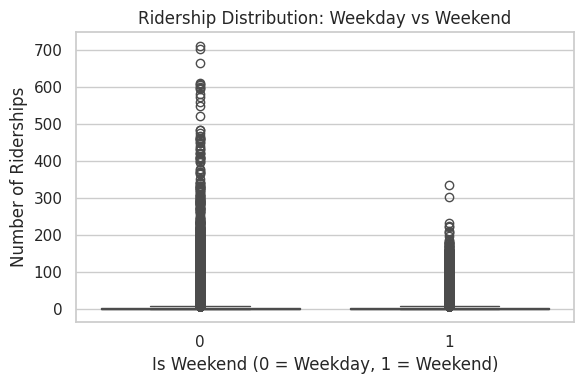

In [ ]:
sns.set(style='whitegrid')
plt.figure(figsize=(6, 4))
sns.boxplot(x='is_weekend', y='Riderships', data=df)
plt.title("Ridership Distribution: Weekday vs Weekend")
plt.xlabel("Is Weekend (0 = Weekday, 1 = Weekend)")
plt.ylabel("Number of Riderships")
plt.tight_layout()
plt.show()

This code creates a boxplot comparing ridership numbers between weekdays and weekends to visualize differences in their distributions.

### **Plot 2: Holiday vs Non-Holiday**

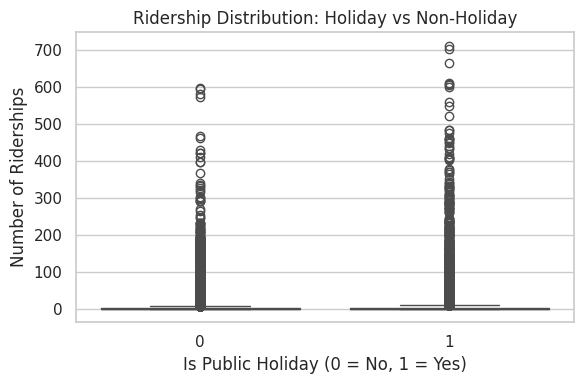

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='is_holiday', y='Riderships', data=df)
plt.title("Ridership Distribution: Holiday vs Non-Holiday")
plt.xlabel("Is Public Holiday (0 = No, 1 = Yes)")
plt.ylabel("Number of Riderships")
plt.tight_layout()
plt.show()

This code creates a boxplot showing how ridership numbers differ between public holidays and non-holidays.

### **Plot 3: Ridership distribution by holiday and peak hour**

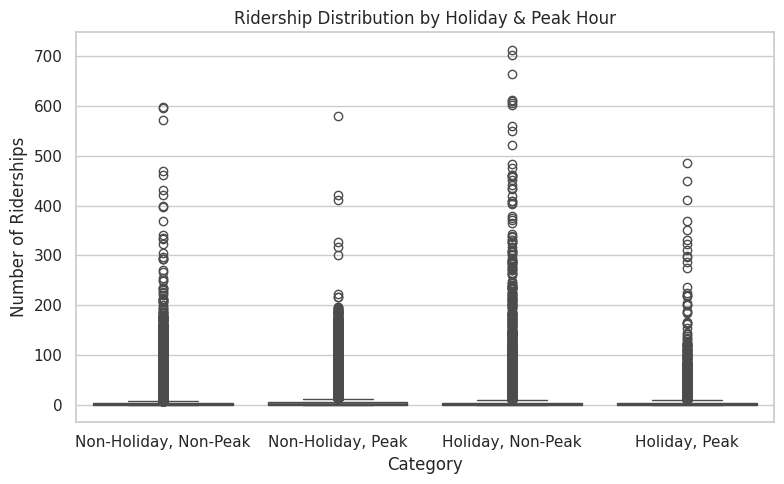

                          count      mean        std  min  25%  50%  75%  \
holiday_peak_label                                                         
Holiday, Non-Peak       49538.0  5.602265  18.769041  1.0  1.0  2.0  5.0   
Holiday, Peak           18847.0  5.524752  14.430073  1.0  1.0  2.0  5.0   
Non-Holiday, Non-Peak  533647.0  3.838908   7.643963  1.0  1.0  2.0  4.0   
Non-Holiday, Peak      252514.0  6.594054  13.480305  1.0  1.0  2.0  6.0   

                         max  
holiday_peak_label            
Holiday, Non-Peak      712.0  
Holiday, Peak          485.0  
Non-Holiday, Non-Peak  598.0  
Non-Holiday, Peak      580.0  


In [ ]:
# Create a new column for combined category
df['holiday_peak'] = df['is_holiday'].astype(str) + "_" + df['is_peak_hour'].astype(str)

# Make readable group labels
group_labels = {
    '0_0': 'Non-Holiday, Non-Peak',
    '0_1': 'Non-Holiday, Peak',
    '1_0': 'Holiday, Non-Peak',
    '1_1': 'Holiday, Peak'
}
df['holiday_peak_label'] = df['holiday_peak'].map(group_labels)

plt.figure(figsize=(8, 5))
sns.boxplot(x='holiday_peak_label', y='Riderships', data=df, order=[
    'Non-Holiday, Non-Peak', 'Non-Holiday, Peak', 'Holiday, Non-Peak', 'Holiday, Peak'
])
plt.title('Ridership Distribution by Holiday & Peak Hour')
plt.xlabel('Category')
plt.ylabel('Number of Riderships')
plt.tight_layout()
plt.show()

print(df.groupby('holiday_peak_label')['Riderships'].describe())

This code combines holiday and peak hour info to create four clear groups, then shows how ridership changes across them using a boxplot. It also summarizes the numbers so we can easily see how ridership varies depending on whether it’s a holiday and/or peak time.

## **Interaction between variables and riderships**

### **Strip Plot: Ridership Distribution by Hour**

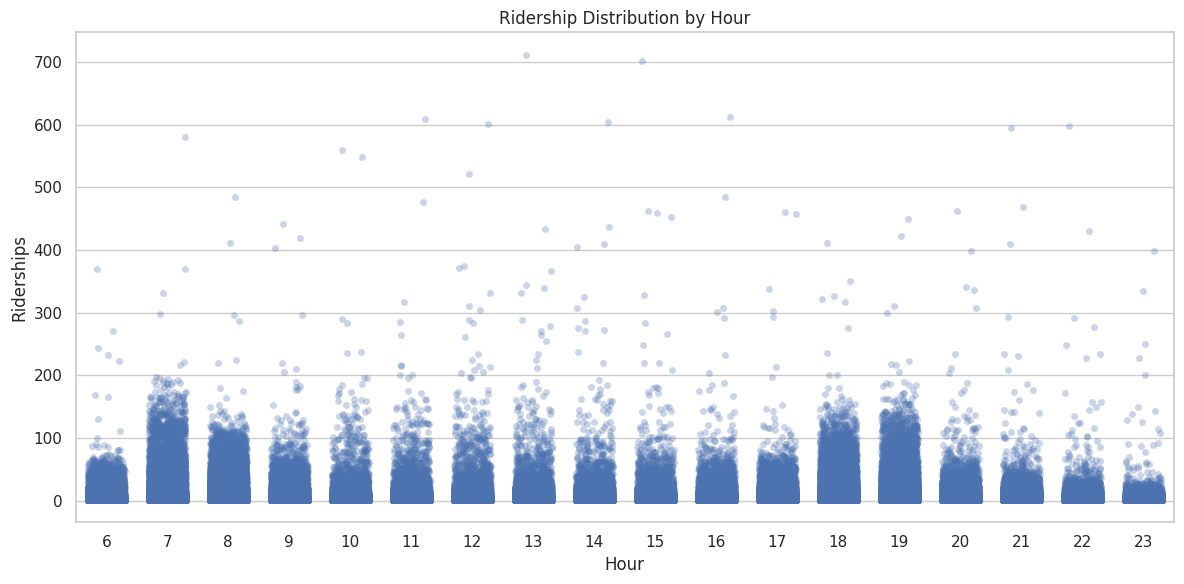

In [ ]:
plt.figure(figsize=(12, 6))
sns.stripplot(x='hour', y='Riderships', data=df_new, alpha=0.3, jitter=0.3)
plt.title("Ridership Distribution by Hour")
plt.xlabel("Hour")
plt.ylabel("Riderships")
plt.tight_layout()
plt.show()

The strip plot highlights strong peak-hour travel behavior during the early morning (7AM-8AM) and evening (6PM-7PM). It shows that hour is a strong predictor.

**However, there are several outliers above 300, 500, and even 700 riderships. This shows the presence of surge events like public holidays, major events, or busy routes.**

This suggests that while hour is a critical predictor of demand, other features such as day type, holiday status, and specific origin-destination pairs also play an important role in explaining ridership fluctuations.

### **Bar Chart: Top 10 Most Used Komuter Routes**

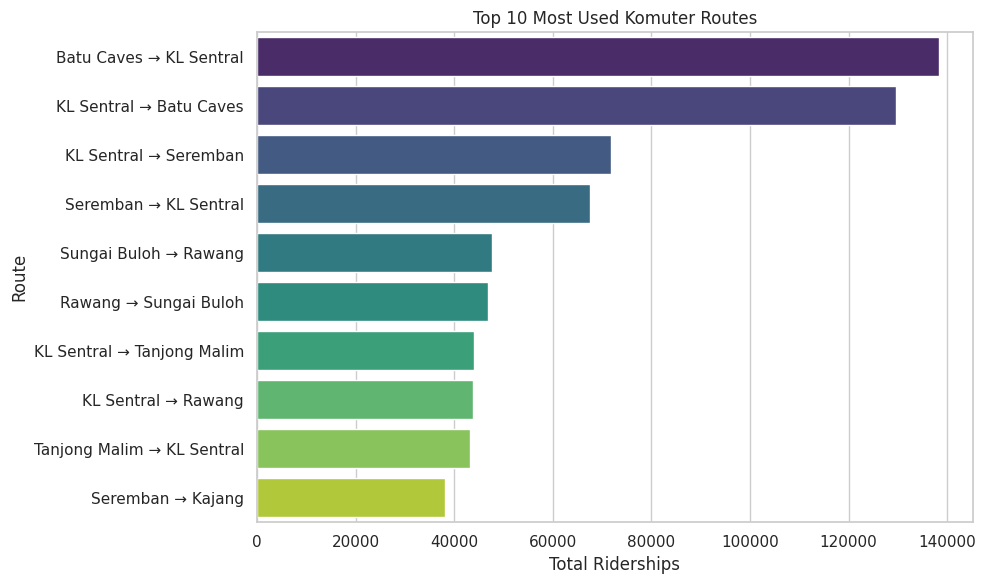

In [ ]:
# Create 'route' column combining origin and destination
df_new['route'] = df_new['origin'] + ' → ' + df_new['destination']

# Group by route and sum passengers
top_routes = df_new.groupby('route')['Riderships'].sum().sort_values(ascending=False).head(10)

# Plot top routes
plt.figure(figsize=(10, 6))
sns.barplot(x=top_routes.values, y=top_routes.index, palette='viridis')
plt.title("Top 10 Most Used Komuter Routes")
plt.xlabel("Total Riderships")
plt.ylabel("Route")
plt.tight_layout()
plt.show()

The route from Batu Caves to KL Sentral has the highest ridership among the top 10 most used Komuter routes shown in the bar chart.

# **Feature encoding**

### **1. Encode day_of_week as ordered categorical codes**


In [ ]:
# Make a working copy for encoding
df_clean = df_new.copy()

# Define the desired ordering of days (Monday = 0, ..., Sunday = 6)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday','Sunday']

# Convert the 'day_of_week' column to an ordered categorical type
df_clean['day_of_week'] = pd.Categorical(df_clean['day_of_week'],
                                         categories=day_order,
                                         ordered=True)

# Extract integer codes for each day (Monday = 0, ..., Sunday = 6)
df_clean['day_of_week_code'] = df_clean['day_of_week'].cat.codes

# Preview the mapping
print("Day-of-week encoding preview:")
print(df_clean[['date', 'day_of_week', 'day_of_week_code']].head())

Day-of-week encoding preview:
          date day_of_week  day_of_week_code
134 2025-01-01   Wednesday                 2
135 2025-01-01   Wednesday                 2
136 2025-01-01   Wednesday                 2
137 2025-01-01   Wednesday                 2
138 2025-01-01   Wednesday                 2


This code:
1. Convert the ‘day_of_week’ column to an ordered categorical type from Monday to Sunday and encode it as integers (Monday = 0, Sunday = 6).

2. Store the integer codes in a new column day_of_week_code and preview the results.

Hence, this output shows the first few rows after encoding the day of the week. Each date is paired with its weekday name (e.g., "Wednesday") and its corresponding numeric code (2), where Monday = 0, Tuesday = 1, and Wednesday = 2. This numeric encoding makes it easier to use the day information in analyses or models.

### **2. Encode station names using LabelEncoder**

In [ ]:
import joblib
# Initialize label encoders for origin and destination
le_origin = LabelEncoder()
le_dest = LabelEncoder()

# Fit and transform origin and destination station names
df_clean['origin_encoded'] = le_origin.fit_transform(df_clean['origin'])
df_clean['destination_encoded'] = le_dest.fit_transform(df_clean['destination'])

# Preview the encoded station values
print("Station encoding preview:")
print(df_clean[['origin', 'origin_encoded', 'destination', 'destination_encoded']].head())

# Save both encoders into a dict
label_encoders = {
    'origin': le_origin,
    'destination': le_dest
}

# Save to disk
import json
label_encoder_data = {
    'origin': le_origin.classes_.tolist(),
    'destination': le_dest.classes_.tolist()
}

with open('label_encoders.json', 'w') as f:
    json.dump(label_encoder_data, f)

Station encoding preview:
             origin  origin_encoded       destination  destination_encoded
134  Abdullah Hukum               0    Kepong Sentral                   20
135  Abdullah Hukum               0  Kampung Raja Uda                   18
136  Abdullah Hukum               0       Padang Jawa                   28
137  Abdullah Hukum               0      Pantai Dalam                   29
138  Abdullah Hukum               0          Petaling                   31


['label_encoders.pkl']

This code encodes the origin and destination station names into numeric labels using LabelEncoder, adds these encoded values as new columns, previews the results, and then saves the encoders to a file (label_encoders.pkl) for later use.

# **Feature selection**

## **Select K-best**

In [ ]:
# Adjust features and target
features = ['year','hour', 'month', 'day_of_week_code', 'is_weekend',
            'is_peak_hour', 'is_holiday', 'origin_encoded', 'destination_encoded']
X = df_clean[features].iloc[:90000]
y = df_clean['Riderships'].iloc[:90000]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X_train, y_train)

feature_scores = pd.DataFrame({
    'Feature': X_train.columns,
    'Score': selector.scores_
}).sort_values(by='Score', ascending=False).reset_index(drop=True)

print(feature_scores)

               Feature       Score
0         is_peak_hour  836.784399
1           is_weekend  266.563911
2       origin_encoded  205.831826
3  destination_encoded  195.206321
4                 hour   46.863690
5           is_holiday   21.064216
6     day_of_week_code    1.934549
7                 year    0.000000
8                month    0.000000


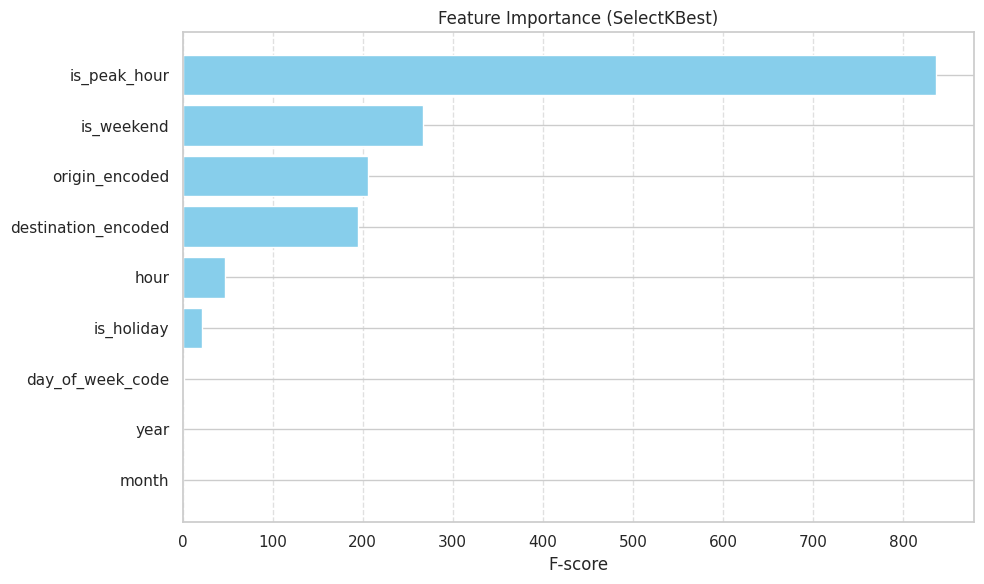

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(feature_scores['Feature'], feature_scores['Score'], color='skyblue')
plt.xlabel('F-score')
plt.title('Feature Importance (SelectKBest)')
plt.gca().invert_yaxis()  # Highest score at the top
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Based on SelectKBest, we select the top 6 features.

# **5. Model Selection**

*   Once your data is ready, you will need to choose an appropriate machine
learning algorithm for your project. You may choose from supervised or unsupervised
learning, and select the model based on the problem you are trying to solve.

For model selection, we choose five algorithms: Random Forest, XGBoost, LightGBM, CatBoost, and ExtraTrees.

# **6. Model Training and Hyperparameter tuning**

*   Once you have selected the model, you will
need to train it on your preprocessed data and evaluate its performance using appropriate metrics. You may need to fine-tune your model to improve its performance.

## **Model Training**

In [ ]:
# Select features
selected_features= [
    'hour', 'is_weekend', 'is_peak_hour', 'is_holiday',
     'origin_encoded', 'destination_encoded'
]
target= 'Riderships'
X = df_clean[features].iloc[:90000]
y = df_clean['Riderships'].iloc[:90000]

X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

print("Train set shape:", X_train_selected.shape)
print("Test set shape:", X_test_selected.shape)

Train set shape: (72000, 6)
Test set shape: (18000, 6)


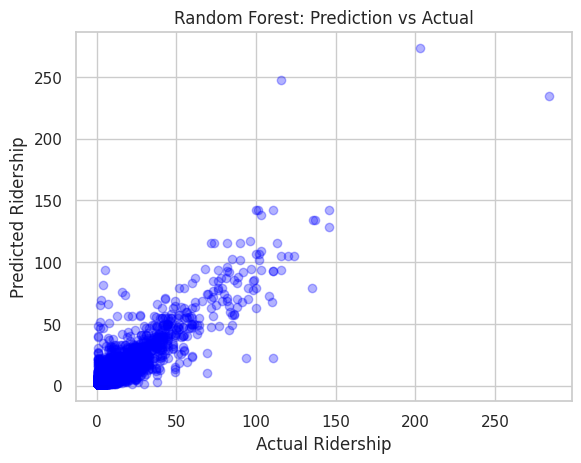

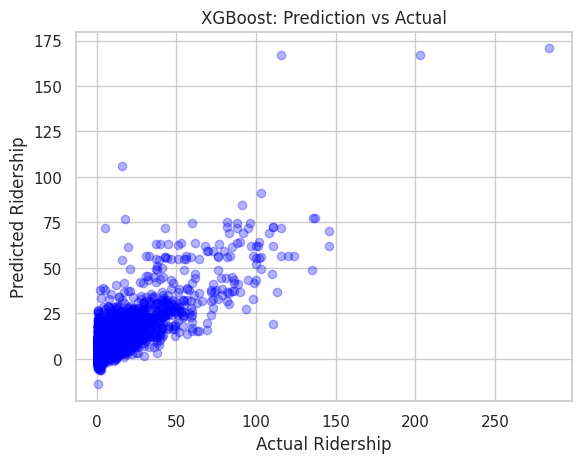

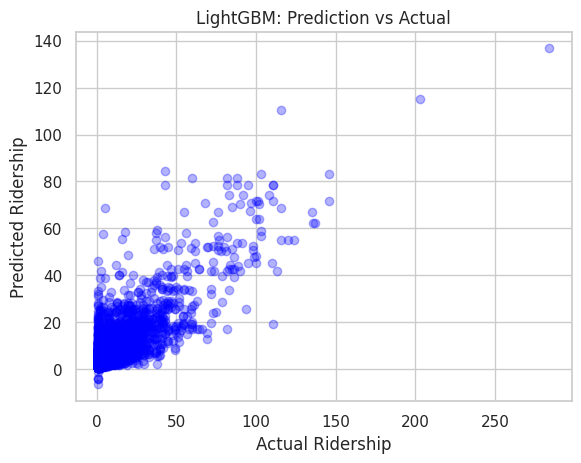

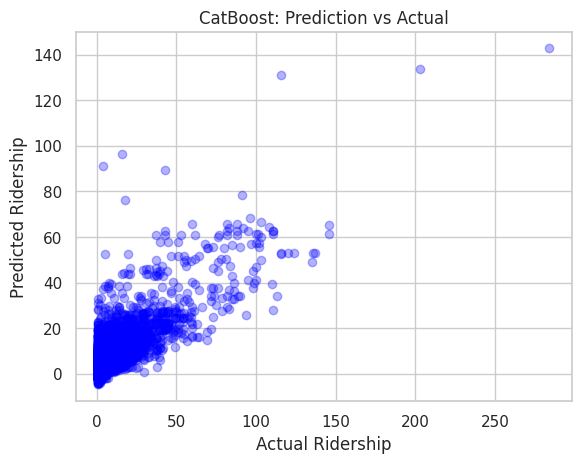

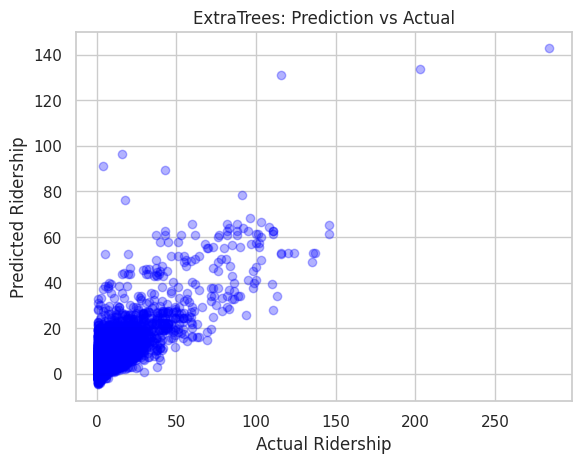

In [ ]:
# --- Train Random Forest Regressor ---
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_selected, y_train)

##  Make predictions
y_pred_rf = rf_model.predict(X_test_selected)

# --- Visualization ---
plt.scatter(y_test, y_pred_rf, alpha=0.3, color='blue')
plt.xlabel("Actual Ridership")
plt.ylabel("Predicted Ridership")
plt.title("Random Forest: Prediction vs Actual")
plt.show()

# --- Train XGBoost Regressor ---
xgb_model = XGBRegressor(objective='reg:squarederror')
xgb_model.fit(X_train_selected, y_train)

y_pred_xgb = xgb_model.predict(X_test_selected)

# --- Visualization ---
plt.scatter(y_test, y_pred_xgb, alpha=0.3, color='blue')
plt.xlabel("Actual Ridership")
plt.ylabel("Predicted Ridership")
plt.title("XGBoost: Prediction vs Actual")
plt.show()

# --- Train LightGBM Regressor ---
lgb_model = LGBMRegressor(
    boosting_type='gbdt',
    objective='regression',
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)
lgb_model.fit(X_train_selected, y_train)

y_pred_lgb = lgb_model.predict(X_test_selected)

# --- Visualization ---
plt.scatter(y_test, y_pred_lgb, alpha=0.3, color='blue')
plt.xlabel("Actual Ridership")
plt.ylabel("Predicted Ridership")
plt.title("LightGBM: Prediction vs Actual")
plt.grid(True)
plt.show()

# --- Train CatBoost ---
cat_model = CatBoostRegressor(verbose=0, random_state=42)
cat_model.fit(X_train_selected, y_train)

y_pred_cat = cat_model.predict(X_test_selected)

# --- Visualization ---
plt.scatter(y_test, y_pred_cat, alpha=0.3, color='blue')
plt.xlabel("Actual Ridership")
plt.ylabel("Predicted Ridership")
plt.title("CatBoost: Prediction vs Actual")
plt.show()

# --- Train ExtraTress ---
etr_model = ExtraTreesRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)
etr_model.fit(X_train_selected, y_train)

y_pred_etr = cat_model.predict(X_test_selected)

# --- Visualization ---
plt.scatter(y_test, y_pred_etr, alpha=0.3, color='blue')
plt.xlabel("Actual Ridership")
plt.ylabel("Predicted Ridership")
plt.title("ExtraTrees: Prediction vs Actual")
plt.show()

##**Hyperparameter tuning**

**Random forest**

In [ ]:
# Define parameter search space for Random Forest
param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

# Setup randomized search
search_rf = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_dist_rf,
    n_iter=30,        # Number of combinations to try
    scoring='r2',     # Use R² as performance metric
    cv=2,
    verbose=1,
    n_jobs=-1
)

# Fit search to training data
search_rf.fit(X_train_selected, y_train)

# Use the best estimator to predict
best_rf = search_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test_selected)

# Evaluate the tuned model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

# Print results
print("Best Parameters:", search_rf.best_params_)
print(f"Tuned Random Forest Performance:")
print(f"MAE : {mae_rf:.2f}")
print(f"RMSE: {rmse_rf:.2f}")
print(f"R²  : {r2_rf:.4f}")

Fitting 2 folds for each of 30 candidates, totalling 60 fits
Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
Tuned Random Forest Performance:
MAE : 1.91
RMSE: 4.30
R²  : 0.7802


**XGBoost Model**

In [ ]:
# Define parameter search space for XGBoost
param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 6, 9, 12],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Setup randomized search
search_xgb = RandomizedSearchCV(
    estimator=XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1),
    param_distributions=param_dist_xgb,
    n_iter=30,         # Number of combinations to try
    scoring='r2',      # Use R² as performance metric
    cv=2,
    verbose=1,
    n_jobs=-1
)

# Fit search to training data
search_xgb.fit(X_train_selected, y_train)

# Use the best estimator to predict
best_xgb = search_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test_selected)

# Evaluate the tuned model
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

# Print results
print("Best Parameters:", search_xgb.best_params_)
print(f"Tuned XGBoost Performance:")
print(f"MAE : {mae_xgb:.2f}")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"R²  : {r2_xgb:.4f}")

import joblib
# Save the tuned model
joblib.dump(best_xgb, 'xgb_model.pkl')

Fitting 2 folds for each of 30 candidates, totalling 60 fits
Best Parameters: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 12, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Tuned XGBoost Performance:
MAE : 1.79
RMSE: 3.84
R²  : 0.8246


['xgb_model.pkl']

**LightGBM Regressor**

In [ ]:
# Define parameter search space for LightGBM
param_dist_lgb = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [6, 9, 12, 15, -1],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'num_leaves': [31, 50, 70, 100, 150],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_samples': [10, 20, 30, 50],
    'reg_alpha': [0, 0.1, 0.5, 1.0],
    'reg_lambda': [0, 0.1, 0.5, 1.0],
    'min_split_gain': [0.0, 0.01, 0.05]
}

# Setup randomized search
search_lgb = RandomizedSearchCV(
    estimator=LGBMRegressor(objective='regression', random_state=42, verbose=-1),
    param_distributions=param_dist_lgb,
    n_iter=30,          # Number of combinations to try
    scoring='r2',       # Use R² as performance metric
    cv=2,
    verbose=1,
    n_jobs=-1
)

# Fit search to training data
search_lgb.fit(X_train_selected, y_train)

# Use the best estimator to predict
best_lgb = search_lgb.best_estimator_
y_pred_lgb = best_lgb.predict(X_test_selected)

# Evaluate the tuned model
mae_lgb = mean_absolute_error(y_test, y_pred_lgb)
rmse_lgb = np.sqrt(mean_squared_error(y_test, y_pred_lgb))
r2_lgb = r2_score(y_test, y_pred_lgb)

# Print results
print("Best Parameters:", search_lgb.best_params_)
print(f"Tuned LightGBM Performance:")
print(f"MAE : {mae_lgb:.2f}")
print(f"RMSE: {rmse_lgb:.2f}")
print(f"R²  : {r2_lgb:.4f}")

Fitting 2 folds for each of 30 candidates, totalling 60 fits
Best Parameters: {'subsample': 1.0, 'reg_lambda': 0.5, 'reg_alpha': 0.1, 'num_leaves': 150, 'n_estimators': 300, 'min_split_gain': 0.05, 'min_child_samples': 10, 'max_depth': -1, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Tuned LightGBM Performance:
MAE : 1.88
RMSE: 4.01
R²  : 0.8088


**CatBoost Regressor**

In [ ]:
# Define parameter search space for CatBoost
param_dist_cat = {
    'iterations': [100, 200, 300],
    'depth': [3, 6, 9, 12],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

# Setup randomized search
search_cat = RandomizedSearchCV(
    estimator=CatBoostRegressor(loss_function='RMSE', random_state=42, verbose=0),
    param_distributions=param_dist_cat,
    n_iter=30,          # Number of combinations to try
    scoring='r2',       # Use R² as performance metric
    cv=2,
    verbose=1,
    n_jobs=-1
)

# Fit search to training data
search_cat.fit(X_train_selected, y_train)

# Use the best estimator to predict
best_cat = search_cat.best_estimator_
y_pred_cat = best_cat.predict(X_test_selected)

# Evaluate the tuned model
mae_cat = mean_absolute_error(y_test, y_pred_cat)
rmse_cat = np.sqrt(mean_squared_error(y_test, y_pred_cat))
r2_cat = r2_score(y_test, y_pred_cat)

# Print results
print("Best Parameters:", search_cat.best_params_)
print(f"Tuned CatBoost Performance:")
print(f"MAE : {mae_cat:.2f}")
print(f"RMSE: {rmse_cat:.2f}")
print(f"R²  : {r2_cat:.4f}")

Fitting 2 folds for each of 30 candidates, totalling 60 fits
Best Parameters: {'subsample': 0.8, 'learning_rate': 0.1, 'iterations': 300, 'depth': 12}
Tuned CatBoost Performance:
MAE : 2.25
RMSE: 4.56
R²  : 0.7524


**ExtraTrees Regressor**

In [ ]:
param_dist_etr = {
    'n_estimators': [300, 500, 700],             # larger ensembles tend to generalize better
    'max_depth': [None, 20, 30, 40],             # allow deeper trees
    'min_samples_split': [2, 3, 5],              # avoid overly coarse splits
    'min_samples_leaf': [1, 2],                  # smaller leaves = higher resolution
    'max_features': ['sqrt', None]               # None = all features; may help if all are informative
}

# Randomized Search with more iterations
search_etr = RandomizedSearchCV(
    estimator=ExtraTreesRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist_etr,
    n_iter=50,               # Increased for better exploration
    scoring='r2',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# Fit to training data
search_etr.fit(X_train_selected, y_train)

# Use the best estimator
best_etr = search_etr.best_estimator_
y_pred_etr = best_etr.predict(X_test_selected)

# Evaluate the tuned model
mae_etr = mean_absolute_error(y_test, y_pred_etr)
rmse_etr = np.sqrt(mean_squared_error(y_test, y_pred_etr))
r2_etr = r2_score(y_test, y_pred_etr)

# Print results
print("Best Parameters:", search_etr.best_params_)
print(f"Tuned ExtraTrees Performance:")
print(f"MAE : {mae_etr:.2f}")
print(f"RMSE: {rmse_etr:.2f}")
print(f"R²  : {r2_etr:.4f}")

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best Parameters: {'n_estimators': 700, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': None}
Tuned ExtraTrees Performance:
MAE : 1.78
RMSE: 3.87
R²  : 0.8219


# **7. Model Evaluation**

In [ ]:
# Create a dictionary with your metrics
evaluation_results = {
    'Model': ['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'Extra Trees'],
    'MAE': [mae_rf, mae_xgb, mae_lgb, mae_cat, mae_etr],
    'RMSE': [rmse_rf, rmse_xgb, rmse_lgb, rmse_cat, rmse_etr],
    'R2 Score': [r2_rf, r2_xgb, r2_lgb, r2_cat, r2_etr]
}

# Convert to DataFrame
results_df = pd.DataFrame(evaluation_results)

# Optional: sort by R² Score (highest first)
results_df = results_df.sort_values(by='R2 Score', ascending=False).reset_index(drop=True)

# Display the table
print(results_df)

           Model       MAE      RMSE  R2 Score
0        XGBoost  1.771818  3.792531  0.828694
1    Extra Trees  1.779810  3.866602  0.821937
2       LightGBM  1.878542  4.006199  0.808847
3  Random Forest  1.906784  4.295867  0.780205
4       CatBoost  2.254408  4.559165  0.752437


In [ ]:
# Strip spaces and replace non-breaking spaces
results_df.columns = results_df.columns.str.replace('\xa0', ' ', regex=True).str.strip()

# Now get the best model
best_model_row = results_df.loc[results_df['R2 Score'].idxmax()]

# Print best model results
print("Best Model Based on R² Score:")
print(f"Model       : {best_model_row['Model']}")
print(f"MAE         : {best_model_row['MAE']:.4f}")
print(f"RMSE        : {best_model_row['RMSE']:.4f}")
print(f"R² Score    : {best_model_row['R2 Score']:.4f}")

Best Model Based on R² Score:
Model       : XGBoost
MAE         : 1.7718
RMSE        : 3.7925
R² Score    : 0.8287


**Residual distribution**

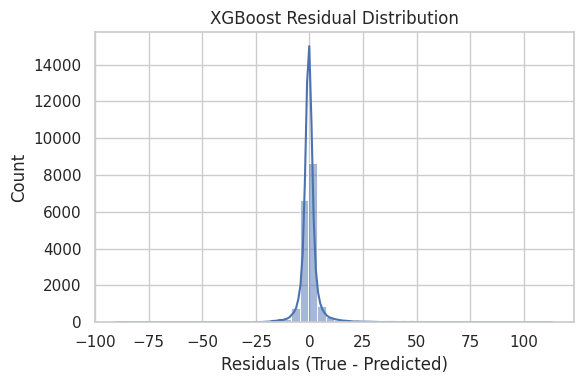

In [ ]:
model_dict = {
    'Random Forest': rf_model,
    'XGBoost': xgb_model,
    'LightGBM': lgb_model,
    'CatBoost': cat_model,
    'Extra Trees': etr_model
}

# Get best model name from results_df
best_model_name = results_df.loc[results_df['R2 Score'].idxmax()]['Model']

# Use best model from model dictionary (make sure this exists)
best_model = model_dict[best_model_name]

# Predict using the best model
y_pred = best_model.predict(X_test_selected)

# Calculate residuals
residuals = y_test - y_pred

# Plot residual distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.histplot(residuals, bins=50, kde=True)
plt.xlabel("Residuals (True - Predicted)")
plt.title(f"{best_model_name} Residual Distribution")
plt.tight_layout()
plt.show()

In [ ]:
!pip install auto-sklearn2

In [ ]:
from auto_sklearn2 import AutoSklearnRegressor

# Create and fit the auto-sklearn regressor
auto_sklearn = AutoSklearnRegressor(time_limit=120, random_state=42)
auto_sklearn.fit(X_train, y_train)

# Make predictions
y_pred = auto_sklearn.predict(X_test)

# Calculate metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Best model: {auto_sklearn.best_params}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"R² Score: {r2:.4f}")

# Show all models performance
for model_name, score in auto_sklearn.get_models_performance().items():
    print(f"{model_name}: {score:.4f}")

Best model: {'preprocessor': 'standard_scaler', 'regressor': 'random_forest'}
Mean Squared Error: 4.4303
Mean Absolute Error: 1.9256
R² Score: 0.7662
standard_scaler_random_forest: 0.7380
standard_scaler_gradient_boosting: 0.1965
standard_scaler_linear_regression: 0.0205
standard_scaler_ridge: 0.0205
standard_scaler_lasso: -0.0000
standard_scaler_elastic_net: 0.0064
standard_scaler_svr: -0.0562


#**8. Conclusion**

In this project, we developed a complete machine learning pipeline to predict hourly Komuter ridership using structured features such as time, station codes, and calendar-based indicators. The pipeline encompassed all key stages of an ML workflow — including data cleaning, feature engineering, feature selection, model training, hyperparameter tuning, evaluation, and result saving.

To ensure robust performance and compare predictive power, we implemented and evaluated five different regression models. Each model was assessed using standard performance metrics such as MAE, RMSE, and R² score on the test set. Feature selection techniques like SelectKBest were applied to retain the most relevant inputs, and model optimization was conducted using RandomizedSearchCV.

The results demonstrate that our pipeline can effectively forecast ridership trends, with some models performing better than others depending on the complexity and flexibility of their architectures. This suggests that model choice and tuning significantly impact accuracy in real-world transport prediction tasks.

The trained models and outputs have been saved for future deployment or deeper analysis.

**Joblib**

In [ ]:
import joblib

models = {
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "LightGBM": lgb_model,
    "CatBoost": cat_model,
    "Extra Trees": etr_model
}

xgb_model = models["XGBoost"]
joblib.dump(xgb_model, 'xgb_model.pkl')

['xgb_model.pkl']

**app.py**

In [ ]:
app_code = """
import streamlit as st
import numpy as np
import pandas as pd
import joblib
import datetime
import xgboost as xgb

# Load model
model = joblib.load("xgb_model.pkl")
label_encoders = joblib.load("label_encoders.pkl")

# Set page
st.set_page_config(page_title="Komuter Ridership Predictor", layout="centered")
st.title("🚆 Komuter Ridership Prediction App")
st.markdown("Predict hourly Komuter ridership based on date, time, and trip details.")

# Form input
with st.form("prediction_form"):
    date_input = st.date_input("Select Date", datetime.date.today())
    time_input = st.time_input("Select Time", datetime.time(8, 0))

    origin_name = st.selectbox("Origin Station", label_encoders['origin'].classes_.tolist())
    destination_name = st.selectbox("Destination Station", label_encoders['destination'].classes_.tolist())

    submit = st.form_submit_button("Predict Ridership")

if submit:
    # Combine date and time
    datetime_combined = datetime.datetime.combine(date_input, time_input)
    hour = datetime_combined.hour
    day_of_week = datetime_combined.weekday()  # Monday=0, Sunday=6
    month = datetime_combined.month

    # Derived features
    is_weekend = 1 if day_of_week >= 5 else 0
    is_peak_hour = 1 if (7 <= hour <= 9) or (17 <= hour <= 19) else 0
    malaysia_holidays = pd.Series(pd.date_range("2025-01-01", "2025-12-31")).map(lambda d: d in pd.Series(pd.date_range("2025-01-01", "2025-12-31")))  # Replace with actual holiday check
    is_holiday = 1 if date_input in malaysia_holidays else 0  # Placeholder

    # Encode stations
    origin_encoded = label_encoders['origin'].transform([origin_name])[0]
    destination_encoded = label_encoders['destination'].transform([destination_name])[0]

    # Prepare feature array
    features = np.array([[hour, is_peak_hour, is_weekend, is_holiday, origin_encoded, destination_encoded]])
    features_scaled = scaler.transform(features)

    # Predict
    prediction = model.predict(features_scaled)[0]

    # Output
    st.subheader("Prediction Result")
    st.info(f"Estimated Ridership: *{int(prediction):,} passengers*")
"""

# Save to app.py
with open("app.py", "w") as f:
    f.write(app_code.strip())

print("app.py has been created!")

app.py has been created!


**requirement.txt**

In [ ]:
requirements = """
streamlit
pandas
numpy
scikit-learn
joblib
matplotlib
seaborn
xgboost
lightgbm
catboost
"""

with open("requirements.txt", "w") as f:
    f.write(requirements.strip())

print("requirements.txt has been created!")


requirements.txt has been created!
